# TP1 - Taller de Programación - Grupo 6

Arias Christian

Avila Angel Leonardo

Vallejo Enrique

In [1]:
# ============================================================
# 0. LIBRERÍAS Y CONFIGURACIÓN GENERAL
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

CARPETA = Path(".")
ARCHIVO_2024 = CARPETA / "usu_individual_T424.xlsx"
ARCHIVO_2025 = CARPETA / "usu_individual_T425.xlsx"
CARPETA_SALIDA = CARPETA / "salidas_tp1"
CARPETA_SALIDA.mkdir(exist_ok=True)

## Parte I - Incisos 1 y 2.a

Se seleccionan 20 variables de interés. A ellas se agregan las
variables de identificación de personas y dos ponderadores específicos de
ingresos. Se conservan más identificadores que los ejemplos mínimos de la
consigna para no perder la posibilidad de identificar de manera unívoca a una
persona y su hogar.

In [2]:
# ============================================================
# 1. SELECCIÓN DE VARIABLES Y LECTURA DE LAS BASES
# ============================================================

# Variables de identificación de la base Personas
VARIABLES_ID = [
    "CODUSU",
    "ANO4",
    "TRIMESTRE",
    "NRO_HOGAR",
    "COMPONENTE",
    "H15",
    "REGION",
    "MAS_500",
    "AGLOMERADO",
    "PONDERA",
]

# 20 variables de interés
# Incluye 13 obligatorias y 7 adicionales
VARIABLES_INTERES = [
    # Obligatorias
    "CH04",          # Sexo
    "CH06",          # Edad
    "CH07",          # Estado civil
    "CH08",          # Cobertura médica
    "NIVEL_ED",      # Nivel educativo
    "ESTADO",        # Condición de actividad
    "CAT_OCUP",      # Categoría ocupacional
    "EMPLEO",        # Empleo formal/informal
    "SECTOR",        # Sector formal/informal/hogares
    "PP04C",         # Tamaño del establecimiento
    "PP04D_COD",     # Código de ocupación (CNO)
    "P21",           # Ingreso de la ocupación principal
    "P47T",          # Ingreso total individual
    # Adicionales
    "CH03",          # Relación de parentesco
    "INTENSI",       # Intensidad de la ocupación
    "PP04A",         # Establecimiento estatal/privado/otro
    "PP04B_COD",     # Código de actividad económica (CAES)
    "PP04G",         # Lugar donde realiza principalmente sus tareas
    "PP07H",         # Descuento jubilatorio realizado por el empleador
    "PP07I",         # Aporte jubilatorio realizado por el propio trabajador
]

# Ponderadores específicos recomendados por el manual para ingresos.
# Se conservan como variables auxiliares
VARIABLES_PONDERACION_INGRESOS = [
    "PONDIIO",  # Ponderador para P21
    "PONDII",   # Ponderador para P47T
]

VARIABLES_A_LEER = (
    VARIABLES_ID
    + VARIABLES_INTERES
    + VARIABLES_PONDERACION_INGRESOS
)


def leer_base(archivo, columnas_necesarias):
    """Lee solo las columnas necesarias y muestra un error claro si falta alguna."""
    try:
        return pd.read_excel(archivo, usecols=columnas_necesarias)
    except ValueError as error:
        raise ValueError(
            f"No se pudieron leer todas las columnas requeridas de {archivo.name}. "
            "Revise los nombres de las variables."
        ) from error


# Se leen solo las columnas que se usarán
eph24_original = leer_base(ARCHIVO_2024, VARIABLES_A_LEER)
eph25_original = leer_base(ARCHIVO_2025, VARIABLES_A_LEER)

# Chequeos básicos de año y trimestre
assert set(eph24_original["ANO4"].dropna().unique()) == {2024}
assert set(eph25_original["ANO4"].dropna().unique()) == {2025}
assert set(eph24_original["TRIMESTRE"].dropna().unique()) == {4}
assert set(eph25_original["TRIMESTRE"].dropna().unique()) == {4}

print("Dimensiones de las bases leídas:")
print("2024T4:", eph24_original.shape)
print("2025T4:", eph25_original.shape)

# Comparación de tipos originales entre años
tipos_originales = pd.DataFrame({
    "Tipo 2024 antes de limpiar": eph24_original[VARIABLES_A_LEER].dtypes.astype(str),
    "Tipo 2025 antes de limpiar": eph25_original[VARIABLES_A_LEER].dtypes.astype(str),
})

display(tipos_originales)

Dimensiones de las bases leídas:
2024T4: (46860, 32)
2025T4: (43703, 32)


,Tipo 2024 antes de limpiar,Tipo 2025 antes de limpiar
CODUSU,object,object
ANO4,int64,int64
TRIMESTRE,int64,int64
NRO_HOGAR,int64,int64
COMPONENTE,int64,int64
H15,int64,int64
REGION,int64,int64
MAS_500,object,object
AGLOMERADO,int64,int64
PONDERA,int64,int64


## Parte I - Inciso 2.b: limpieza y armonización

Criterios:

- Los códigos de no respuesta (por ejemplo 9, 99 y códigos especiales del CNO)
  se convierten a `NaN` cuando el manual los identifica como NS/NR.
- Los ceros de variables que no corresponden por secuencia se convierten a
  `NaN` en las variables ocupacionales. No se cambia `ESTADO = 0`, porque ese
  valor es necesario para separar a quienes no respondieron el cuestionario individual.
- En `P21` y `P47T`, todo valor negativo se considera un código especial de
  no respuesta y se convierte a `NaN`. Los ingresos iguales a cero se conservan:
  cero no es lo mismo que un dato faltante.
- `PP04D_COD` se armoniza como texto de cinco caracteres porque el manual
  lo define como un campo de caracteres.
- En `CH06`, el valor observado `-1` se recodifica como 0 años cumplidos
  (menores de un año), y las edades fuera de un rango plausible se convierten a `NaN`.

In [3]:
# ============================================================
# 2. LIMPIEZA Y ARMONIZACIÓN
# ============================================================


def limpiar_y_armonizar(base):
    """Limpia los códigos especiales y armoniza los tipos de datos."""
    df = base.copy()

    # Identificadores de tipo texto
    df["CODUSU"] = df["CODUSU"].astype("string")
    df["MAS_500"] = df["MAS_500"].astype("string")

    # Conversión general a numérico, excepto identificadores de texto y CNO
    columnas_numericas = [
        col for col in VARIABLES_A_LEER
        if col not in ["CODUSU", "MAS_500", "PP04D_COD"]
    ]

    for col in columnas_numericas:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Edad: -1 corresponde a menores de un año en estas bases.
    df.loc[df["CH06"] == -1, "CH06"] = 0
    df.loc[~df["CH06"].between(0, 110), "CH06"] = np.nan

    # Códigos de no respuesta o de no correspondencia que deben ser NaN
    codigos_a_nan = {
        "CH07": [9],
        "CH08": [9],
        "NIVEL_ED": [9],
        "CAT_OCUP": [0, 9],
        "EMPLEO": [9],
        "SECTOR": [9],
        "PP04C": [0, 99],
        "INTENSI": [9],
        "PP04A": [0, 9],
        "PP04B_COD": [0, 9999, 99999],
        "PP04G": [0, 99],
        "PP07H": [0, 9],
        "PP07I": [0, 9],
    }

    for variable, codigos in codigos_a_nan.items():
        df.loc[df[variable].isin(codigos), variable] = np.nan

    # Código de ocupación: el manual lo define como carácter de longitud 5
    cno = pd.to_numeric(df["PP04D_COD"], errors="coerce")
    cno = cno.mask(cno.isin([99997, 99998, 99999]))
    df["PP04D_COD"] = cno.astype("Int64").astype("string").str.zfill(5)

    # Ingresos: los negativos son códigos especiales; el cero se conserva
    for variable in ["P21", "P47T"]:
        df.loc[df[variable] < 0, variable] = np.nan
        df[variable] = df[variable].astype("float64")

    # Códigos numéricos como enteros anulables de pandas
    # Así pueden convivir números enteros y valores faltantes
    columnas_enteras = [
        col for col in columnas_numericas
        if col not in ["P21", "P47T"]
    ]

    for col in columnas_enteras:
        df[col] = df[col].round().astype("Int64")

    return df


eph24 = limpiar_y_armonizar(eph24_original)
eph25 = limpiar_y_armonizar(eph25_original)

# Tipos finales: deben coincidir entre 2024 y 2025.
tipos_finales = pd.DataFrame({
    "Tipo final 2024": eph24[VARIABLES_A_LEER].dtypes.astype(str),
    "Tipo final 2025": eph25[VARIABLES_A_LEER].dtypes.astype(str),
})

tipos_finales["Coinciden"] = (
    tipos_finales["Tipo final 2024"] == tipos_finales["Tipo final 2025"]
)

display(tipos_finales)
assert tipos_finales["Coinciden"].all(), "Todavía existen tipos distintos entre años."

# Resumen simple del efecto de la limpieza sobre los faltantes
faltantes_antes = pd.DataFrame({
    "2024 antes (%)": eph24_original[VARIABLES_INTERES].isna().mean() * 100,
    "2025 antes (%)": eph25_original[VARIABLES_INTERES].isna().mean() * 100,
})

faltantes_despues = pd.DataFrame({
    "2024 después (%)": eph24[VARIABLES_INTERES].isna().mean() * 100,
    "2025 después (%)": eph25[VARIABLES_INTERES].isna().mean() * 100,
})

resumen_limpieza = pd.concat([faltantes_antes, faltantes_despues], axis=1).round(2)
display(resumen_limpieza)

,Tipo final 2024,Tipo final 2025,Coinciden
CODUSU,string,string,True
ANO4,Int64,Int64,True
TRIMESTRE,Int64,Int64,True
NRO_HOGAR,Int64,Int64,True
COMPONENTE,Int64,Int64,True
H15,Int64,Int64,True
REGION,Int64,Int64,True
MAS_500,string,string,True
AGLOMERADO,Int64,Int64,True
PONDERA,Int64,Int64,True


,2024 antes (%),2025 antes (%),2024 después (%),2025 después (%)
CH04,0.00,0.00,0.00,0.00
CH06,0.00,0.00,0.00,0.00
CH07,0.00,0.00,0.00,0.01
CH08,0.00,0.00,0.10,0.25
NIVEL_ED,0.00,0.00,0.00,0.00
ESTADO,0.00,0.00,0.00,0.00
CAT_OCUP,0.00,0.00,52.89,52.70
EMPLEO,54.90,54.93,54.94,54.95
SECTOR,54.90,54.93,56.73,56.64
PP04C,54.90,54.93,63.69,64.16


## Parte I - Inciso 3: respondieron y no respondieron

In [4]:
# ============================================================
# 3. UNIÓN DE AÑOS Y SEPARACIÓN SEGÚN ESTADO
# ============================================================

# Se unen las bases ya limpias y armonizadas
eph = pd.concat([eph24, eph25], ignore_index=True)

# ESTADO = 0 significa entrevista individual no realizada
respondieron = eph[eph["ESTADO"] != 0].copy()
norespondieron = eph[eph["ESTADO"] == 0].copy()

conteo_norespondieron = (
    norespondieron
    .groupby("ANO4")
    .size()
    .rename("No respondieron ESTADO")
)

print("Personas que no respondieron su condición de actividad, por año:")
display(conteo_norespondieron.to_frame())
print("Total 2024 + 2025:", len(norespondieron))

print("Dimensión de respondieron:", respondieron.shape)
print("Dimensión de norespondieron:", norespondieron.shape)

respondieron.to_csv(CARPETA_SALIDA / "respondieron.csv", index=False)
norespondieron.to_csv(CARPETA_SALIDA / "norespondieron.csv", index=False)

Personas que no respondieron su condición de actividad, por año:


,No respondieron ESTADO
ANO4,
2024,56
2025,65


Total 2024 + 2025: 121
Dimensión de respondieron: (90442, 32)
Dimensión de norespondieron: (121, 32)


## Parte I - Inciso 4: base de ocupados

In [5]:
# ============================================================
# 4. BASE DE OCUPADOS
# ============================================================

ocupados = respondieron[respondieron["ESTADO"] == 1].copy()

print("Cantidad de ocupados, por año:")
display(ocupados.groupby("ANO4").size().rename("Ocupados").to_frame())
print("Total de ocupados:", len(ocupados))

Cantidad de ocupados, por año:


,Ocupados
ANO4,
2024,21132
2025,19698


Total de ocupados: 40830


## Parte I - Inciso 5: variables dicotómicas

Las variables binarias conservan `NaN` cuando la variable original está
faltante. De este modo, una no respuesta no se transforma artificialmente en 0

In [6]:
# ============================================================
# 5. CREACIÓN DE VARIABLES DICOTÓMICAS
# ============================================================


def crear_dummy(serie, valores_que_valen_uno):
    """Crea una dummy 0/1 y conserva NaN si la variable de origen es NaN."""
    resultado = pd.Series(pd.NA, index=serie.index, dtype="Int64")
    observados = serie.notna()
    resultado.loc[observados] = (
        serie.loc[observados].isin(valores_que_valen_uno).astype("int64")
    )
    return resultado


# Sexo y estado civil
ocupados["mujer"] = crear_dummy(ocupados["CH04"], [2])
ocupados["casado"] = crear_dummy(ocupados["CH07"], [2])
ocupados["unido_o_casado"] = crear_dummy(ocupados["CH07"], [1, 2])

# Cobertura médica: 4 significa que no paga ni le descuentan
ocupados["con_cobertura_medica"] = crear_dummy(
    ocupados["CH08"],
    [1, 2, 3, 12, 13, 23, 123]
)

# Secundario completo o un nivel superior
# NIVEL_ED = 7 es "sin instrucción"
ocupados["secundario_completo_o_mas"] = crear_dummy(
    ocupados["NIVEL_ED"],
    [4, 5, 6]
)

# Categoría ocupacional
ocupados["asalariado"] = crear_dummy(ocupados["CAT_OCUP"], [3])
ocupados["cuenta_propia"] = crear_dummy(ocupados["CAT_OCUP"], [2])

# Indicadores de formalidad ya incluidos por la EPH
ocupados["empleo_informal_eph"] = crear_dummy(ocupados["EMPLEO"], [2])
ocupados["sector_informal"] = crear_dummy(ocupados["SECTOR"], [2])

# Tipo de establecimiento e intensidad horaria
ocupados["sector_publico"] = crear_dummy(ocupados["PP04A"], [1])
ocupados["ocupado_pleno"] = crear_dummy(ocupados["INTENSI"], [2])

# Descuento jubilatorio del asalariado
ocupados["con_descuento_jubilatorio"] = crear_dummy(ocupados["PP07H"], [1])
ocupados["sin_descuento_jubilatorio"] = crear_dummy(ocupados["PP07H"], [2])

VARIABLES_DUMMY = [
    "mujer",
    "casado",
    "unido_o_casado",
    "con_cobertura_medica",
    "secundario_completo_o_mas",
    "asalariado",
    "cuenta_propia",
    "empleo_informal_eph",
    "sector_informal",
    "sector_publico",
    "ocupado_pleno",
    "con_descuento_jubilatorio",
    "sin_descuento_jubilatorio",
]

print("Promedio de las dummies (proporción no ponderada entre casos observados):")
display(ocupados[VARIABLES_DUMMY].mean().to_frame("Promedio").round(3))

Promedio de las dummies (proporción no ponderada entre casos observados):


,Promedio
mujer,0.45
casado,0.25
unido_o_casado,0.54
con_cobertura_medica,0.70
secundario_completo_o_mas,0.71
asalariado,0.72
cuenta_propia,0.24
empleo_informal_eph,0.44
sector_informal,0.24
sector_publico,0.21


## Parte I - Inciso 6: actualización de ingresos

Se utiliza un factor de 1,3141, calculado como el cociente entre el promedio
del IPC nacional de octubre-diciembre de 2025 y el promedio de octubre-diciembre
de 2024. El factor queda escrito de manera explícita para que pueda reemplazarse
eventualmente

In [7]:
# ============================================================
# 6. ACTUALIZACIÓN DE P21 Y P47T A PESOS DE 2025T4
# ============================================================

FACTOR_IPC_2024T4_A_2025T4 = 1.314106232

# Se conservan las variables nominales por transparencia y reproducibilidad
eph["P21_NOMINAL"] = eph["P21"]
eph["P47T_NOMINAL"] = eph["P47T"]

# Se actualizan los ingresos de 2024; 2025 queda sin cambios
mascara_2024 = eph["ANO4"] == 2024

eph.loc[mascara_2024, "P21"] = (
    eph.loc[mascara_2024, "P21"] * FACTOR_IPC_2024T4_A_2025T4
)

eph.loc[mascara_2024, "P47T"] = (
    eph.loc[mascara_2024, "P47T"] * FACTOR_IPC_2024T4_A_2025T4
)

# Se reconstruyen las sub bases para que todas contengan los ingresos actualizados
respondieron = eph[eph["ESTADO"] != 0].copy()
norespondieron = eph[eph["ESTADO"] == 0].copy()
ocupados = respondieron[respondieron["ESTADO"] == 1].copy()

# Se vuelven a crear las dummies en la nueva versión de ocupados
ocupados["mujer"] = crear_dummy(ocupados["CH04"], [2])
ocupados["casado"] = crear_dummy(ocupados["CH07"], [2])
ocupados["unido_o_casado"] = crear_dummy(ocupados["CH07"], [1, 2])
ocupados["con_cobertura_medica"] = crear_dummy(
    ocupados["CH08"], [1, 2, 3, 12, 13, 23, 123]
)
ocupados["secundario_completo_o_mas"] = crear_dummy(
    ocupados["NIVEL_ED"], [4, 5, 6]
)
ocupados["asalariado"] = crear_dummy(ocupados["CAT_OCUP"], [3])
ocupados["cuenta_propia"] = crear_dummy(ocupados["CAT_OCUP"], [2])
ocupados["empleo_informal_eph"] = crear_dummy(ocupados["EMPLEO"], [2])
ocupados["sector_informal"] = crear_dummy(ocupados["SECTOR"], [2])
ocupados["sector_publico"] = crear_dummy(ocupados["PP04A"], [1])
ocupados["ocupado_pleno"] = crear_dummy(ocupados["INTENSI"], [2])
ocupados["con_descuento_jubilatorio"] = crear_dummy(ocupados["PP07H"], [1])
ocupados["sin_descuento_jubilatorio"] = crear_dummy(ocupados["PP07H"], [2])

print("Factor aplicado:", round(FACTOR_IPC_2024T4_A_2025T4, 4))
print("Promedios de ingresos positivos, por año, en pesos de 2025T4:")

promedios_ingresos = (
    ocupados
    .assign(
        P21_positivo=ocupados["P21"].where(ocupados["P21"] > 0),
        P47T_positivo=ocupados["P47T"].where(ocupados["P47T"] > 0),
    )
    .groupby("ANO4")[["P21_positivo", "P47T_positivo"]]
    .mean()
    .round(2)
)

display(promedios_ingresos)

Factor aplicado: 1.3141
Promedios de ingresos positivos, por año, en pesos de 2025T4:


,P21_positivo,P47T_positivo
ANO4,,
2024,"847,967.38","954,174.48"
2025,"938,616.95","1,055,204.73"


## Parte I - Inciso 7: heatmap de faltantes

El número total de observaciones se incorpora dentro de las etiquetas de las
columnas del propio heatmap

,"Respondieron 2024\n(n=46,804)","Respondieron 2025\n(n=43,638)","Ocupados 2024\n(n=21,132)","Ocupados 2025\n(n=19,698)"
Sexo,0.00,0.00,0.00,0.00
Edad,0.00,0.00,0.00,0.00
Estado civil,0.00,0.00,0.00,0.01
Cobertura médica,0.09,0.24,0.10,0.16
Nivel educativo,0.00,0.00,0.00,0.00
Condición de actividad,0.00,0.00,0.00,0.00
Categoría ocupacional,52.83,52.63,0.00,0.00
Empleo formal/informal,54.88,54.88,0.08,0.05
Sector formal/informal/hogares,56.68,56.58,4.06,3.81
Tamaño del establecimiento,63.65,64.11,19.49,20.49


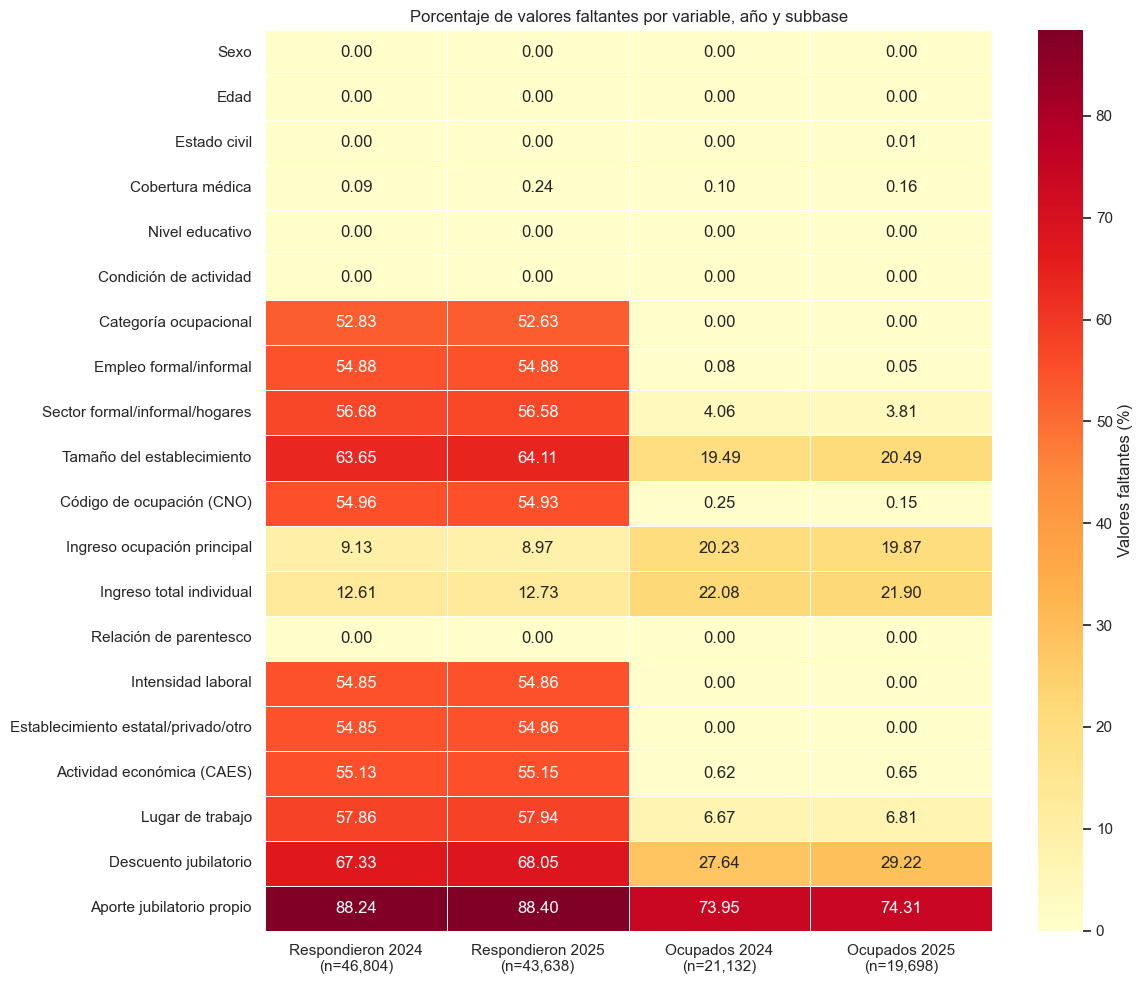

In [8]:
# ============================================================
# 7. PORCENTAJE DE VALORES FALTANTES
# ============================================================

ETIQUETAS_VARIABLES = {
    "CH04": "Sexo",
    "CH06": "Edad",
    "CH07": "Estado civil",
    "CH08": "Cobertura médica",
    "NIVEL_ED": "Nivel educativo",
    "ESTADO": "Condición de actividad",
    "CAT_OCUP": "Categoría ocupacional",
    "EMPLEO": "Empleo formal/informal",
    "SECTOR": "Sector formal/informal/hogares",
    "PP04C": "Tamaño del establecimiento",
    "PP04D_COD": "Código de ocupación (CNO)",
    "P21": "Ingreso ocupación principal",
    "P47T": "Ingreso total individual",
    "CH03": "Relación de parentesco",
    "INTENSI": "Intensidad laboral",
    "PP04A": "Establecimiento estatal/privado/otro",
    "PP04B_COD": "Actividad económica (CAES)",
    "PP04G": "Lugar de trabajo",
    "PP07H": "Descuento jubilatorio",
    "PP07I": "Aporte jubilatorio propio",
}


def porcentaje_faltantes(base, variables):
    return base[variables].isna().mean() * 100


resp24 = respondieron[respondieron["ANO4"] == 2024]
resp25 = respondieron[respondieron["ANO4"] == 2025]
ocup24 = ocupados[ocupados["ANO4"] == 2024]
ocup25 = ocupados[ocupados["ANO4"] == 2025]

faltantes = pd.DataFrame({
    f"Respondieron 2024\n(n={len(resp24):,})": porcentaje_faltantes(resp24, VARIABLES_INTERES),
    f"Respondieron 2025\n(n={len(resp25):,})": porcentaje_faltantes(resp25, VARIABLES_INTERES),
    f"Ocupados 2024\n(n={len(ocup24):,})": porcentaje_faltantes(ocup24, VARIABLES_INTERES),
    f"Ocupados 2025\n(n={len(ocup25):,})": porcentaje_faltantes(ocup25, VARIABLES_INTERES),
}).round(2)

faltantes_presentacion = faltantes.rename(index=ETIQUETAS_VARIABLES)
display(faltantes_presentacion)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    faltantes_presentacion,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Valores faltantes (%)"},
    ax=ax,
)
ax.set_title("Porcentaje de valores faltantes por variable, año y subbase")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(CARPETA_SALIDA / "inciso7_heatmap_faltantes.png", dpi=300, bbox_inches="tight")
plt.show()

**Borrador:**

La ausencia de datos es muy baja en las variables sociodemográficas básicas,
pero aumenta en las variables laborales cuando se analiza la base `respondieron`,
porque muchas preguntas solo se realizan a personas ocupadas. Al restringir la
muestra a `ocupados`, desaparece gran parte de esa falta estructural. Aun así,
permanecen porcentajes altos en `PP07H` y `PP07I`, dado que esas preguntas se
aplican principalmente a asalariados, y en `PP04C`, donde además existe no
respuesta sobre el tamaño del establecimiento. Los patrones son muy similares
entre 2024T4 y 2025T4.

## Parte II - Inciso 8: matrices de correlación

Se usa `respondieron`, no `ocupados`, porque en la base de ocupados `ESTADO`
vale siempre 1 y su correlación no puede calcularse. Se usa correlación por pares,
evitando eliminar una observación completa por un faltante en otra variable.
Las correlaciones de códigos categóricos deben interpretarse con cautela, ya que
sus números son etiquetas y no magnitudes económicas.

Matriz de correlación 2024T4


,Sector,Estado,Categoría ocupacional,Ingreso principal,Ingreso total,Nivel educativo,Sexo,Edad,Estado civil,Cobertura médica
Sector,1.00,NaN,-0.17,-0.38,-0.34,-0.35,0.17,0.00,0.05,0.31
Estado,NaN,1.00,0.03,-0.59,-0.50,-0.17,0.11,-0.30,0.38,0.02
Categoría ocupacional,-0.17,0.03,1.00,0.02,-0.00,0.05,0.08,-0.17,0.08,-0.13
Ingreso principal,-0.38,-0.59,0.02,1.00,0.86,0.23,-0.14,0.14,-0.27,-0.10
Ingreso total,-0.34,-0.50,-0.00,0.86,1.00,0.24,-0.10,0.39,-0.34,-0.14
Nivel educativo,-0.35,-0.17,0.05,0.23,0.24,1.00,0.07,-0.01,-0.07,-0.06
Sexo,0.17,0.11,0.08,-0.14,-0.10,0.07,1.00,0.06,-0.01,-0.01
Edad,0.00,-0.30,-0.17,0.14,0.39,-0.01,0.06,1.00,-0.51,-0.18
Estado civil,0.05,0.38,0.08,-0.27,-0.34,-0.07,-0.01,-0.51,1.00,0.10
Cobertura médica,0.31,0.02,-0.13,-0.10,-0.14,-0.06,-0.01,-0.18,0.10,1.00


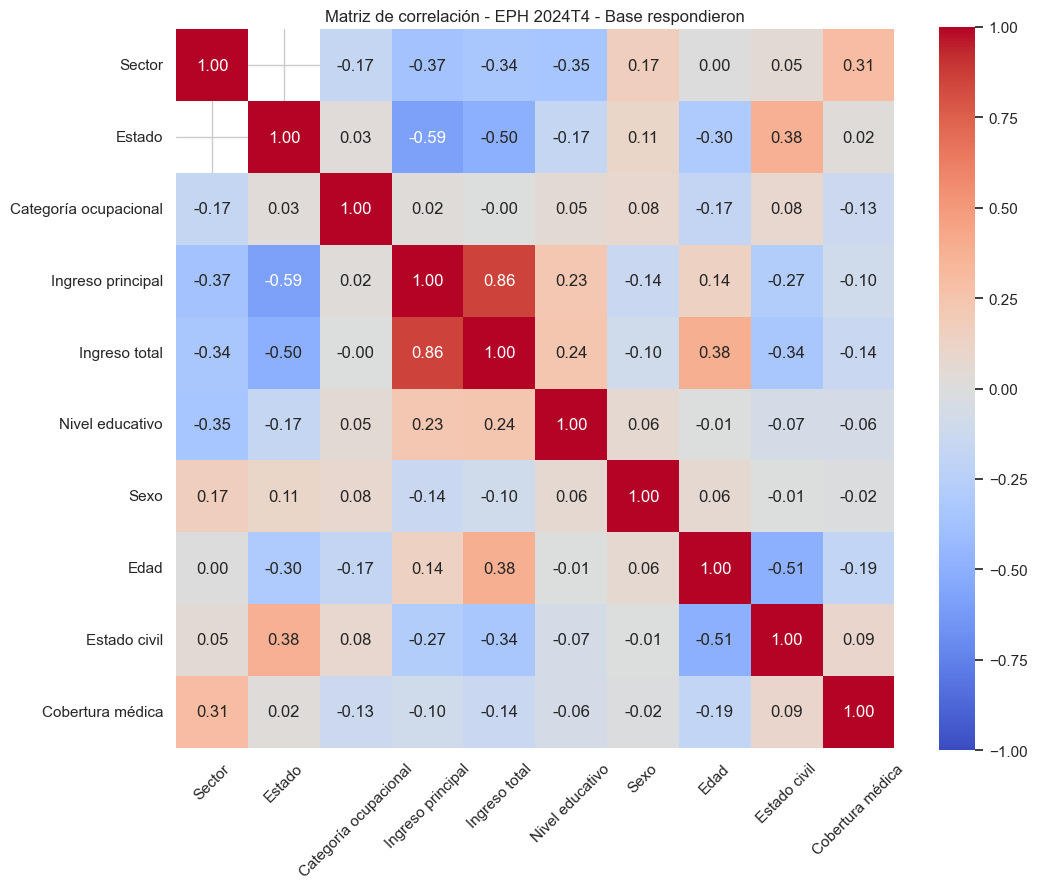

Matriz de correlación 2025T4


,Sector,Estado,Categoría ocupacional,Ingreso principal,Ingreso total,Nivel educativo,Sexo,Edad,Estado civil,Cobertura médica
Sector,1.00,NaN,-0.19,-0.35,-0.31,-0.35,0.17,0.01,0.05,0.36
Estado,NaN,1.00,0.04,-0.58,-0.48,-0.18,0.11,-0.28,0.37,0.02
Categoría ocupacional,-0.19,0.04,1.00,-0.04,-0.05,0.07,0.07,-0.18,0.09,-0.14
Ingreso principal,-0.35,-0.58,-0.04,1.00,0.86,0.23,-0.14,0.13,-0.27,-0.11
Ingreso total,-0.31,-0.48,-0.05,0.86,1.00,0.24,-0.10,0.35,-0.32,-0.15
Nivel educativo,-0.35,-0.18,0.07,0.23,0.24,1.00,0.07,0.00,-0.08,-0.08
Sexo,0.17,0.11,0.07,-0.14,-0.10,0.07,1.00,0.06,0.00,-0.02
Edad,0.01,-0.28,-0.18,0.13,0.35,0.00,0.06,1.00,-0.50,-0.20
Estado civil,0.05,0.37,0.09,-0.27,-0.32,-0.08,0.00,-0.50,1.00,0.10
Cobertura médica,0.36,0.02,-0.14,-0.11,-0.15,-0.08,-0.02,-0.20,0.10,1.00


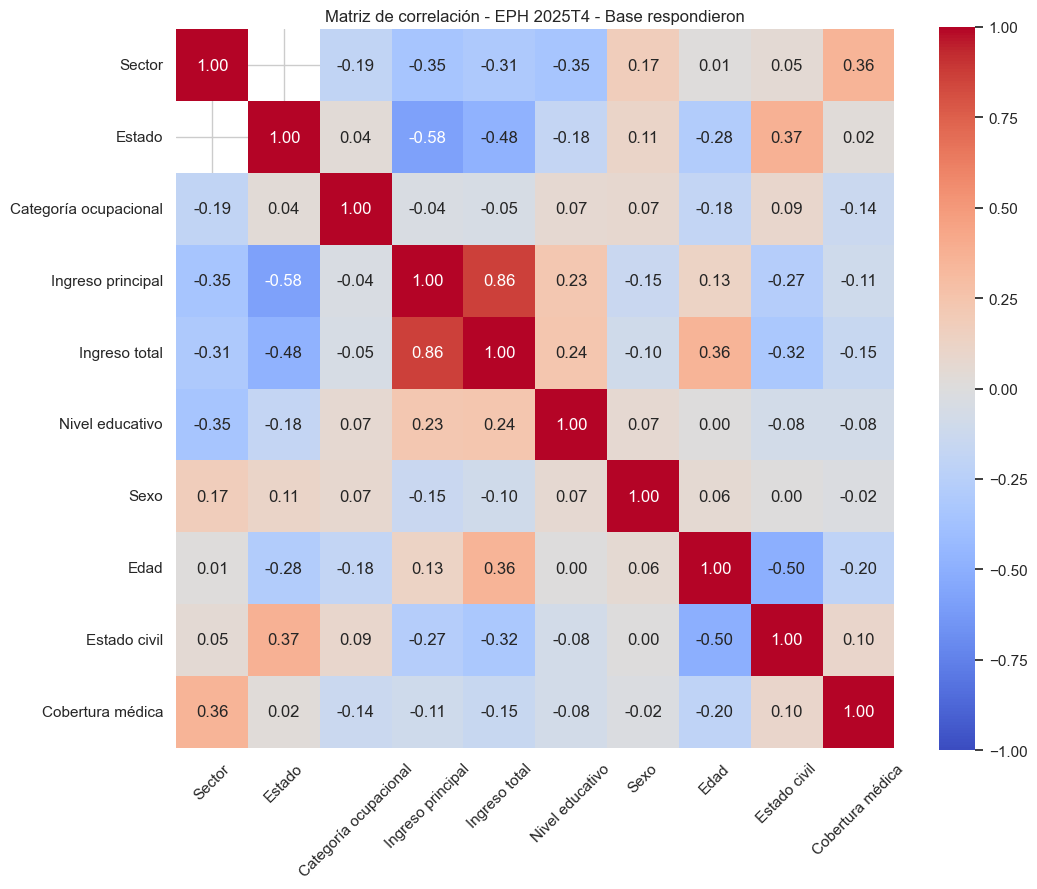

Pares con mayores cambios absolutos:


,Variable 1,Variable 2,Correlación 2024,Correlación 2025,Cambio absoluto
0,CAT_OCUP,P21,0.02,-0.04,0.06
1,CAT_OCUP,P47T,-0.00,-0.05,0.05
2,SECTOR,CH08,0.31,0.36,0.05
3,P47T,CH06,0.39,0.35,0.03
4,SECTOR,P21,-0.38,-0.35,0.03
5,SECTOR,P47T,-0.34,-0.31,0.03
6,ESTADO,CH06,-0.30,-0.28,0.02
7,ESTADO,P47T,-0.50,-0.48,0.02
8,CH06,CH08,-0.18,-0.20,0.02
9,NIVEL_ED,CH08,-0.06,-0.08,0.02


In [9]:
# ============================================================
# 8. MATRICES DE CORRELACIÓN 2024T4 Y 2025T4
# ============================================================

VARIABLES_CORR = [
    "SECTOR",
    "ESTADO",
    "CAT_OCUP",
    "P21",
    "P47T",
    "NIVEL_ED",
    "CH04",
    "CH06",
    "CH07",
    "CH08",
]

ETIQUETAS_CORR = {
    "SECTOR": "Sector",
    "ESTADO": "Estado",
    "CAT_OCUP": "Categoría ocupacional",
    "P21": "Ingreso principal",
    "P47T": "Ingreso total",
    "NIVEL_ED": "Nivel educativo",
    "CH04": "Sexo",
    "CH06": "Edad",
    "CH07": "Estado civil",
    "CH08": "Cobertura médica",
}

matrices_corr = {}

for anio in [2024, 2025]:
    datos_anio = (
        respondieron.loc[respondieron["ANO4"] == anio, VARIABLES_CORR]
        .apply(pd.to_numeric, errors="coerce")
    )

    # pandas calcula cada correlación con los casos válidos de ese par.
    matriz = datos_anio.corr(min_periods=50)
    matrices_corr[anio] = matriz

    matriz_presentacion = matriz.rename(
        index=ETIQUETAS_CORR,
        columns=ETIQUETAS_CORR,
    )

    print(f"Matriz de correlación {anio}T4")
    display(matriz_presentacion.round(3))

    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(
        matriz_presentacion,
        vmin=-1,
        vmax=1,
        center=0,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        square=True,
        ax=ax,
    )
    ax.set_title(f"Matriz de correlación - EPH {anio}T4 - Base respondieron")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    fig.savefig(
        CARPETA_SALIDA / f"inciso8_correlacion_{anio}T4.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

# Diferencias absolutas entre las matrices
cambio_corr = (matrices_corr[2025] - matrices_corr[2024]).abs()

# Se listan solo los pares por encima de la diagonal para no repetirlos.
cambios_pares = []
for i, variable_1 in enumerate(VARIABLES_CORR):
    for j, variable_2 in enumerate(VARIABLES_CORR):
        if j > i and pd.notna(cambio_corr.loc[variable_1, variable_2]):
            cambios_pares.append({
                "Variable 1": variable_1,
                "Variable 2": variable_2,
                "Correlación 2024": matrices_corr[2024].loc[variable_1, variable_2],
                "Correlación 2025": matrices_corr[2025].loc[variable_1, variable_2],
                "Cambio absoluto": cambio_corr.loc[variable_1, variable_2],
            })

cambios_pares = (
    pd.DataFrame(cambios_pares)
    .sort_values("Cambio absoluto", ascending=False)
    .reset_index(drop=True)
)

print("Pares con mayores cambios absolutos:")
display(cambios_pares.head(10).round(3))

**Borrador:**

Las matrices muestran una estructura bastante estable entre 2024T4 y 2025T4.
El mayor cambio absoluto es pequeño, por lo que no se observa una modificación
generalizada de las asociaciones. Debe evitarse una lectura causal: además, varias
variables son categóricas y sus códigos numéricos no representan distancias
comparables. La asociación positiva alta entre `P21` y `P47T` es esperable porque
el ingreso de la ocupación principal forma parte del ingreso total individual.

## Parte II - Inciso 9: estadística descriptiva

La tabla principal se calcula en `respondieron`, por año. También se generan
tablas para `ocupados` como material adicional

In [10]:
# ============================================================
# 9. TABLAS DE ESTADÍSTICA DESCRIPTIVA
# ============================================================


def tabla_descriptiva(base, variables):
    """Devuelve n, media, desvío, min, p1, p25, p50, p75, p99 y max."""
    datos = base[variables].copy()

    # PP04D_COD fue armonizada como texto; se convierte temporalmente a número
    # solo para poder cumplir con la tabla solicitada.
    for col in variables:
        datos[col] = pd.to_numeric(datos[col], errors="coerce")

    tabla = datos.describe(
        percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
    ).T

    tabla = tabla.rename(columns={
        "count": "Observaciones",
        "mean": "Promedio",
        "std": "Desvío estándar",
        "min": "Mínimo",
        "1%": "P1",
        "25%": "P25",
        "50%": "P50",
        "75%": "P75",
        "99%": "P99",
        "max": "Máximo",
    })

    orden = [
        "Observaciones",
        "Promedio",
        "Desvío estándar",
        "Mínimo",
        "P1",
        "P25",
        "P50",
        "P75",
        "P99",
        "Máximo",
    ]

    return tabla[orden]


tablas_desc_respondieron = {}
tablas_desc_ocupados = {}

for anio in [2024, 2025]:
    tablas_desc_respondieron[anio] = tabla_descriptiva(
        respondieron[respondieron["ANO4"] == anio],
        VARIABLES_INTERES,
    )

    tablas_desc_ocupados[anio] = tabla_descriptiva(
        ocupados[ocupados["ANO4"] == anio],
        VARIABLES_INTERES,
    )

    print(f"Estadística descriptiva - respondieron - {anio}T4")
    display(
        tablas_desc_respondieron[anio]
        .rename(index=ETIQUETAS_VARIABLES)
        .round(2)
    )

print("Tablas adicionales para ocupados generadas correctamente.")

Estadística descriptiva - respondieron - 2024T4


,Observaciones,Promedio,Desvío estándar,Mínimo,P1,P25,P50,P75,P99,Máximo
Sexo,"46,804.00",1.52,0.50,1.00,1.00,1.00,2.00,2.00,2.00,2.00
Edad,"46,804.00",36.77,22.18,0.00,1.00,18.00,35.00,54.00,85.00,103.00
Estado civil,"46,804.00",3.52,1.65,1.00,1.00,2.00,5.00,5.00,5.00,5.00
Cobertura médica,"46,762.00",2.13,1.86,1.00,1.00,1.00,1.00,4.00,12.00,123.00
Nivel educativo,"46,804.00",3.78,1.76,1.00,1.00,3.00,4.00,5.00,7.00,7.00
Condición de actividad,"46,804.00",2.18,1.13,1.00,1.00,1.00,3.00,3.00,4.00,4.00
Categoría ocupacional,"22,076.00",2.70,0.54,1.00,1.00,2.00,3.00,3.00,3.00,4.00
Empleo formal/informal,"21,116.00",1.43,0.50,1.00,1.00,1.00,1.00,2.00,2.00,2.00
Sector formal/informal/hogares,"20,275.00",1.38,0.61,1.00,1.00,1.00,1.00,2.00,3.00,3.00
Tamaño del establecimiento,"17,014.00",5.41,3.65,1.00,1.00,2.00,6.00,8.00,12.00,12.00


Estadística descriptiva - respondieron - 2025T4


,Observaciones,Promedio,Desvío estándar,Mínimo,P1,P25,P50,P75,P99,Máximo
Sexo,"43,638.00",1.53,0.50,1.00,1.00,1.00,2.00,2.00,2.00,2.00
Edad,"43,638.00",37.59,22.32,0.00,1.00,19.00,36.00,55.00,86.00,101.00
Estado civil,"43,637.00",3.51,1.65,1.00,1.00,2.00,5.00,5.00,5.00,5.00
Cobertura médica,"43,535.00",2.14,1.74,1.00,1.00,1.00,1.00,4.00,12.00,23.00
Nivel educativo,"43,638.00",3.75,1.74,1.00,1.00,3.00,4.00,5.00,7.00,7.00
Condición de actividad,"43,638.00",2.17,1.12,1.00,1.00,1.00,3.00,3.00,4.00,4.00
Categoría ocupacional,"20,673.00",2.68,0.54,1.00,1.00,2.00,3.00,3.00,3.00,4.00
Empleo formal/informal,"19,688.00",1.44,0.50,1.00,1.00,1.00,1.00,2.00,2.00,2.00
Sector formal/informal/hogares,"18,948.00",1.39,0.62,1.00,1.00,1.00,1.00,2.00,3.00,3.00
Tamaño del establecimiento,"15,662.00",5.22,3.66,1.00,1.00,1.00,5.00,8.00,12.00,12.00


Tablas adicionales para ocupados generadas correctamente.


## Parte III - Inciso 10: definición del Grupo 6

Para el Grupo 6 corresponde **Upper-tier informal wage employees**.
La construcción es:

- Asalariado: `CAT_OCUP == 3`.
- Asalariado formal: `PP07H == 1` (el empleador realiza descuento jubilatorio).
- Asalariado informal upper-tier: `PP07H == 2` y `PP04C` entre 6 y 12.
  Esos códigos de `PP04C` representan establecimientos con más de cinco personas.

`PP07I` no se utiliza para definir upper-tier. Esa variable indica si la persona
aporta por sí misma y no informa el tamaño del establecimiento.

Los porcentajes se ponderan con `PONDERA`. El denominador de la tabla es el
conjunto formado por asalariados formales y asalariados informales upper-tier.
Se informa por separado cuántos asalariados quedan fuera de esa comparación.

In [12]:
# ============================================================
# 10. INFORMALIDAD SEGÚN MAURIZIO Y MONSALVO - GRUPO 6
# ============================================================

asalariados = ocupados[ocupados["CAT_OCUP"] == 3].copy()
asalariados["grupo_informalidad"] = pd.NA

# Formal wage employees
asalariados.loc[
    asalariados["PP07H"] == 1,
    "grupo_informalidad"
] = "Formal wage employees"

# Upper-tier informal wage employees:
# sin descuento jubilatorio y en establecimientos de más de 5 personas.
asalariados.loc[
    (asalariados["PP07H"] == 2)
    & (asalariados["PP04C"].between(6, 12)),
    "grupo_informalidad"
] = "Upper-tier informal wage employees"

# Diagnóstico de cobertura de la clasificación
resumen_clasificacion = []

for anio in [2024, 2025]:
    base_anio = asalariados[asalariados["ANO4"] == anio]
    resumen_clasificacion.append({
        "Año": anio,
        "Asalariados totales": len(base_anio),
        "Formales": (base_anio["grupo_informalidad"] == "Formal wage employees").sum(),
        "Informales upper-tier": (
            base_anio["grupo_informalidad"] == "Upper-tier informal wage employees"
        ).sum(),
        "Fuera de la comparación": base_anio["grupo_informalidad"].isna().sum(),
    })

resumen_clasificacion = pd.DataFrame(resumen_clasificacion)
print("Cobertura de la clasificación:")
display(resumen_clasificacion)

# Base de comparación: solo las dos categorías asignadas
comparacion_informalidad = asalariados.dropna(
    subset=["grupo_informalidad", "PONDERA"]
).copy()

# Se duplican las observaciones para crear una fila "Total" y las filas por sexo
base_total = comparacion_informalidad.copy()
base_total["grupo_sexo"] = "Total"

base_sexo = comparacion_informalidad[
    comparacion_informalidad["CH04"].isin([1, 2])
].copy()
base_sexo["grupo_sexo"] = base_sexo["CH04"].map({1: "Varones", 2: "Mujeres"})

base_tabla = pd.concat([base_total, base_sexo], ignore_index=True)

# Suma de ponderadores por año, sexo y grupo de formalidad
tabla_ponderada = (
    base_tabla
    .groupby(
        ["ANO4", "grupo_sexo", "grupo_informalidad"],
        observed=True,
    )["PONDERA"]
    .sum()
    .unstack(fill_value=0)
)

# Porcentajes dentro de cada año y grupo de sexo
tabla_porcentajes = (
    tabla_ponderada
    .div(tabla_ponderada.sum(axis=1), axis=0)
    * 100
)

orden_filas = pd.MultiIndex.from_product(
    [[2024, 2025], ["Total", "Varones", "Mujeres"]],
    names=["Año", "Grupo"],
)

tabla_porcentajes = tabla_porcentajes.reindex(orden_filas).round(2)

print("Porcentaje ponderado de formales e informales upper-tier:")
display(tabla_porcentajes)

Cobertura de la clasificación:


,Año,Asalariados totales,Formales,Informales upper-tier,Fuera de la comparación
0,2024,15292,9727,1578,3987
1,2025,13943,8815,1377,3751


Porcentaje ponderado de formales e informales upper-tier:


grupo_informalidad  Formal wage employees  Upper-tier informal wage employees
Año  Grupo                                                                   
2024 Total                          86.43                               13.57
     Varones                        86.68                               13.32
     Mujeres                        86.13                               13.87
2025 Total                          87.21                               12.79
     Varones                        86.79                               13.21
     Mujeres                        87.75                               12.25

**Borrador:**

Dentro del universo comparado —asalariados formales y asalariados informales
upper-tier— la proporción ponderada de formales fue aproximadamente 86,4% en
2024T4 y 87,2% en 2025T4, mientras que la participación upper-tier informal
pasó de alrededor de 13,6% a 12,8%. Las diferencias por sexo fueron reducidas:
en 2024 la informalidad upper-tier fue algo mayor entre mujeres, mientras que
en 2025 fue algo mayor entre varones. Estos porcentajes no representan a todos
los asalariados informales, porque la definición asignada excluye a los
informales lower-tier y a los casos sin información suficiente para clasificar.

## Parte III - Inciso 11: distribuciones de P21 y P47T

Se genera una figura de cuatro paneles para cada año. Esto permite comparar
2024 y 2025 sin mezclar ambos períodos en una única distribución. Para que los
valores extremos no aplasten visualmente el resto de la distribución, las
figuras muestran valores positivos hasta el percentil 99. El recorte se aplica
solo al gráfico y no modifica las bases ni las tablas. Para P21 se usa PONDIIO
y para P47T se usa PONDII, tal como recomienda el manual de la EPH.

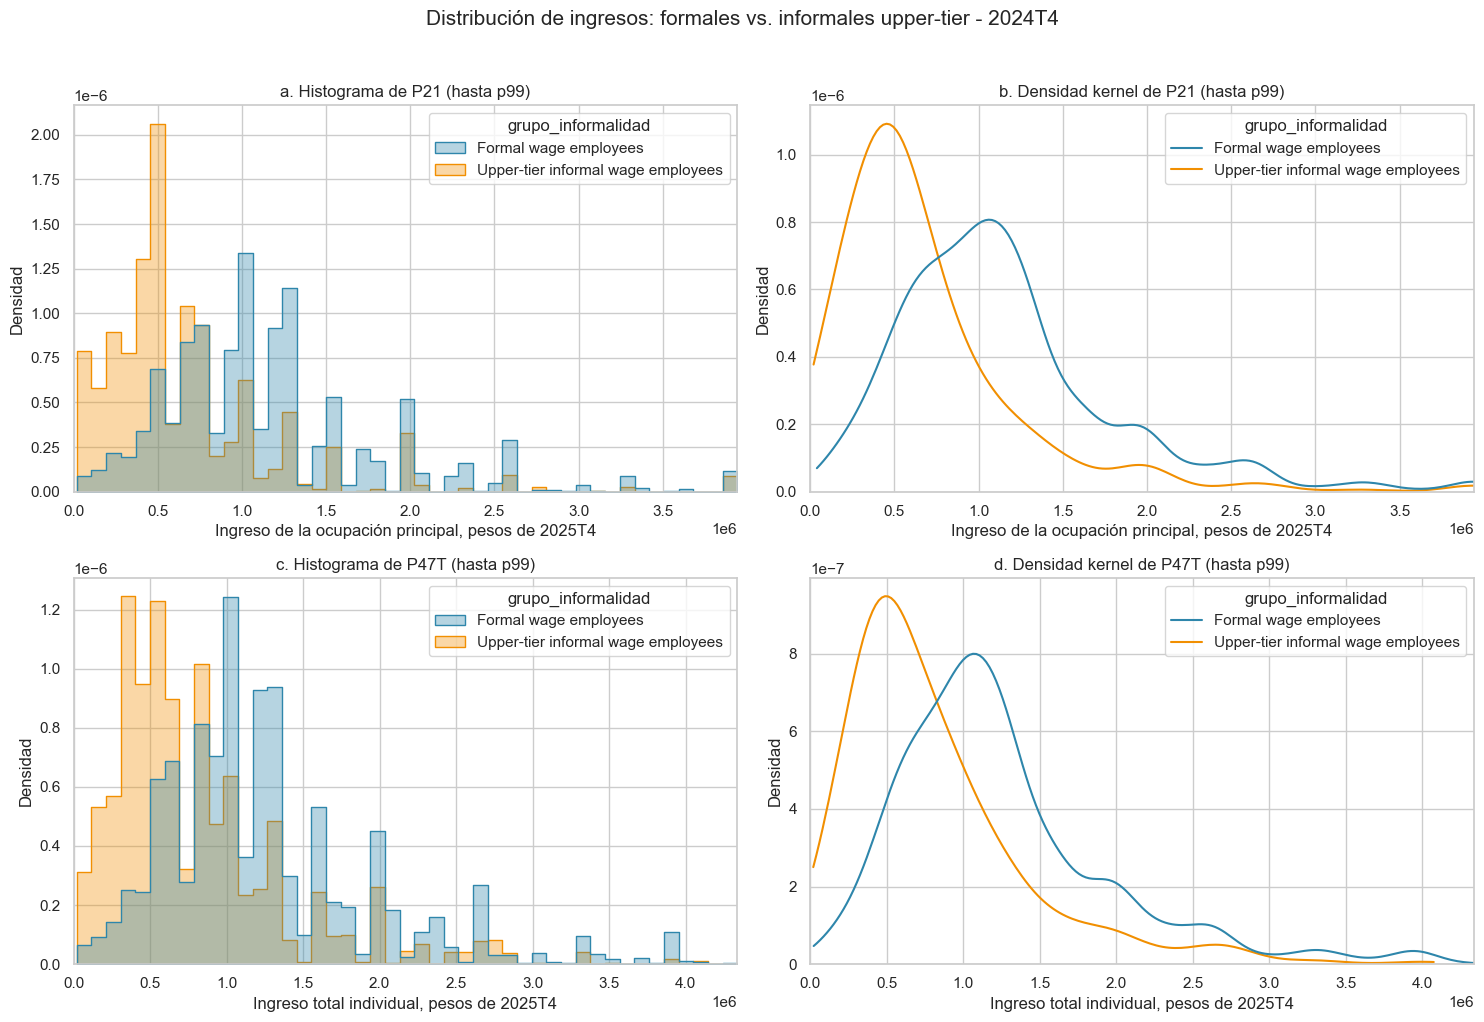

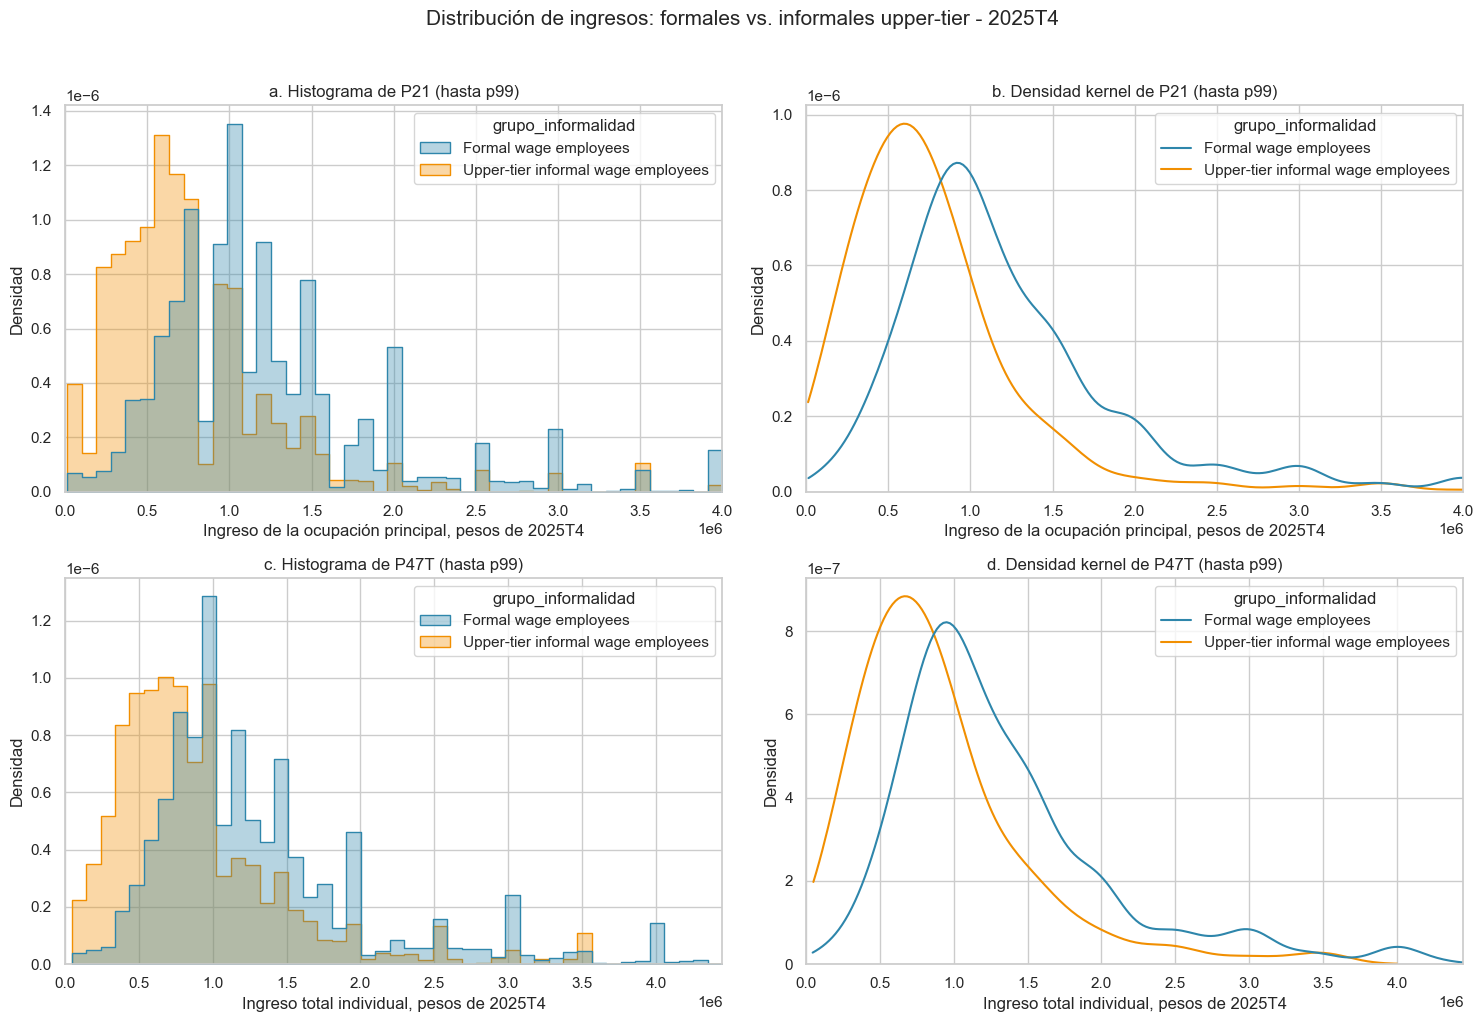

Resumen para interpretar las distribuciones:


,Año,Grupo,Observaciones,Media ponderada P21 (positivos),Mediana P21 (positivos),P21 faltante (%),P21 igual a 0 (%),Media ponderada P47T (positivos),Mediana P47T (positivos),P47T faltante (%),P47T igual a 0 (%)
0,2024,Formal wage employees,9727,"1,216,854.39","1,025,002.86",18.32,0.47,"1,328,218.46","1,051,284.99",20.11,0.31
1,2024,Upper-tier informal wage employees,1578,"702,979.18","459,937.18",12.99,3.11,"871,153.10","525,642.49",15.08,1.71
2,2025,Formal wage employees,8815,"1,321,352.93","1,000,000.00",17.84,0.29,"1,426,705.98","1,100,000.00",19.90,0.24
3,2025,Upper-tier informal wage employees,1377,"833,372.89","560,000.00",11.84,2.98,"979,022.84","650,000.00",14.45,1.60


In [13]:
# ============================================================
# 11. HISTOGRAMAS Y DENSIDADES KERNEL DE INGRESOS
# ============================================================

PALETA_GRUPOS = {
    "Formal wage employees": "#2E86AB",
    "Upper-tier informal wage employees": "#F18F01",
}


def preparar_datos_grafico(base, variable, ponderador):
    """Conserva ingresos positivos y recorta visualmente en el percentil 99."""
    datos = base.dropna(
        subset=[variable, ponderador, "grupo_informalidad"]
    ).copy()
    datos = datos[(datos[variable] > 0) & (datos[ponderador] > 0)].copy()
    limite_p99 = datos[variable].quantile(0.99)
    datos = datos[datos[variable] <= limite_p99].copy()
    return datos, limite_p99


for anio in [2024, 2025]:
    datos_anio = comparacion_informalidad[
        comparacion_informalidad["ANO4"] == anio
    ].copy()

    datos_p21, limite_p21 = preparar_datos_grafico(
        datos_anio, "P21", "PONDIIO"
    )
    datos_p47t, limite_p47t = preparar_datos_grafico(
        datos_anio, "P47T", "PONDII"
    )

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # a. Histograma P21
    sns.histplot(
        data=datos_p21,
        x="P21",
        hue="grupo_informalidad",
        weights="PONDIIO",
        bins=45,
        stat="density",
        common_norm=False,
        element="step",
        alpha=0.35,
        palette=PALETA_GRUPOS,
        ax=axes[0, 0],
    )
    axes[0, 0].set_title("a. Histograma de P21 (hasta p99)")
    axes[0, 0].set_xlabel("Ingreso de la ocupación principal, pesos de 2025T4")
    axes[0, 0].set_ylabel("Densidad")
    axes[0, 0].set_xlim(0, limite_p21)

    # b. Kernel P21
    sns.kdeplot(
        data=datos_p21,
        x="P21",
        hue="grupo_informalidad",
        weights="PONDIIO",
        common_norm=False,
        fill=False,
        cut=0,
        warn_singular=False,
        palette=PALETA_GRUPOS,
        ax=axes[0, 1],
    )
    axes[0, 1].set_title("b. Densidad kernel de P21 (hasta p99)")
    axes[0, 1].set_xlabel("Ingreso de la ocupación principal, pesos de 2025T4")
    axes[0, 1].set_ylabel("Densidad")
    axes[0, 1].set_xlim(0, limite_p21)

    # c. Histograma P47T
    sns.histplot(
        data=datos_p47t,
        x="P47T",
        hue="grupo_informalidad",
        weights="PONDII",
        bins=45,
        stat="density",
        common_norm=False,
        element="step",
        alpha=0.35,
        palette=PALETA_GRUPOS,
        ax=axes[1, 0],
    )
    axes[1, 0].set_title("c. Histograma de P47T (hasta p99)")
    axes[1, 0].set_xlabel("Ingreso total individual, pesos de 2025T4")
    axes[1, 0].set_ylabel("Densidad")
    axes[1, 0].set_xlim(0, limite_p47t)

    # d. Kernel P47T
    sns.kdeplot(
        data=datos_p47t,
        x="P47T",
        hue="grupo_informalidad",
        weights="PONDII",
        common_norm=False,
        fill=False,
        cut=0,
        warn_singular=False,
        palette=PALETA_GRUPOS,
        ax=axes[1, 1],
    )
    axes[1, 1].set_title("d. Densidad kernel de P47T (hasta p99)")
    axes[1, 1].set_xlabel("Ingreso total individual, pesos de 2025T4")
    axes[1, 1].set_ylabel("Densidad")
    axes[1, 1].set_xlim(0, limite_p47t)

    fig.suptitle(
        f"Distribución de ingresos: formales vs. informales upper-tier - {anio}T4",
        fontsize=15,
        y=1.02,
    )
    plt.tight_layout()
    fig.savefig(
        CARPETA_SALIDA / f"inciso11_distribuciones_ingresos_{anio}T4.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


# Tabla de apoyo para comentar las distribuciones y sus faltantes.
def media_ponderada(base, variable, ponderador):
    datos = base[[variable, ponderador]].dropna()
    datos = datos[datos[variable] > 0]
    if len(datos) == 0:
        return np.nan
    return np.average(datos[variable], weights=datos[ponderador])


resumen_ingresos_grupos = []

for (anio, grupo), datos in comparacion_informalidad.groupby(
    ["ANO4", "grupo_informalidad"],
    observed=True,
):
    resumen_ingresos_grupos.append({
        "Año": anio,
        "Grupo": grupo,
        "Observaciones": len(datos),
        "Media ponderada P21 (positivos)": media_ponderada(
            datos, "P21", "PONDIIO"
        ),
        "Mediana P21 (positivos)": datos.loc[datos["P21"] > 0, "P21"].median(),
        "P21 faltante (%)": datos["P21"].isna().mean() * 100,
        "P21 igual a 0 (%)": datos["P21"].eq(0).mean() * 100,
        "Media ponderada P47T (positivos)": media_ponderada(
            datos, "P47T", "PONDII"
        ),
        "Mediana P47T (positivos)": datos.loc[datos["P47T"] > 0, "P47T"].median(),
        "P47T faltante (%)": datos["P47T"].isna().mean() * 100,
        "P47T igual a 0 (%)": datos["P47T"].eq(0).mean() * 100,
    })

resumen_ingresos_grupos = pd.DataFrame(resumen_ingresos_grupos).round(2)
print("Resumen para interpretar las distribuciones:")
display(resumen_ingresos_grupos)

**Borrador:**

En ambos años las distribuciones de ingresos son asimétricas hacia la derecha.
Los asalariados formales presentan una distribución desplazada hacia valores
más altos que los informales upper-tier, tanto en `P21` como en `P47T`. `P21`
mide los ingresos habituales de la ocupación principal, mientras que `P47T`
incorpora ingresos laborales y no laborales, por lo que no son variables
equivalentes. Las comparaciones también están condicionadas por la no respuesta,
por los ingresos iguales a cero y por la presencia de valores extremos. El
recorte al percentil 99 se usa únicamente para mejorar la visualización.

In [14]:
# ============================================================
# 12. EXPORTACIÓN DE RESULTADOS PEQUEÑOS
# ============================================================

# Se guarda un solo libro con las tablas principales. No se exportan las bases
# completas porque son muy grandes y no es necesario para cumplir la consigna.
archivo_resultados = CARPETA_SALIDA / "tablas_tp1_grupo6.xlsx"

with pd.ExcelWriter(archivo_resultados) as writer:
    tipos_originales.to_excel(writer, sheet_name="tipos_originales")
    tipos_finales.to_excel(writer, sheet_name="tipos_finales")
    resumen_limpieza.to_excel(writer, sheet_name="limpieza")
    faltantes_presentacion.to_excel(writer, sheet_name="faltantes")
    matrices_corr[2024].to_excel(writer, sheet_name="corr_2024")
    matrices_corr[2025].to_excel(writer, sheet_name="corr_2025")
    cambios_pares.to_excel(writer, sheet_name="cambios_corr", index=False)
    tablas_desc_respondieron[2024].to_excel(writer, sheet_name="desc_resp_2024")
    tablas_desc_respondieron[2025].to_excel(writer, sheet_name="desc_resp_2025")
    tablas_desc_ocupados[2024].to_excel(writer, sheet_name="desc_ocup_2024")
    tablas_desc_ocupados[2025].to_excel(writer, sheet_name="desc_ocup_2025")
    resumen_clasificacion.to_excel(writer, sheet_name="clasificacion", index=False)
    tabla_porcentajes.to_excel(writer, sheet_name="informalidad_pct")
    resumen_ingresos_grupos.to_excel(writer, sheet_name="ingresos_grupos", index=False)

print("Resultados guardados en:", archivo_resultados)
print("Figuras guardadas en:", CARPETA_SALIDA)

Resultados guardados en: salidas_tp1\tablas_tp1_grupo6.xlsx
Figuras guardadas en: salidas_tp1
